In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../__datasets__/placement.csv')
df.sample(5)

,cgpa,placement_exam_marks,placed
805,6.23,13.0,0
119,7.00,39.0,0
606,6.79,24.0,0
772,6.63,26.0,0
746,6.72,25.0,1


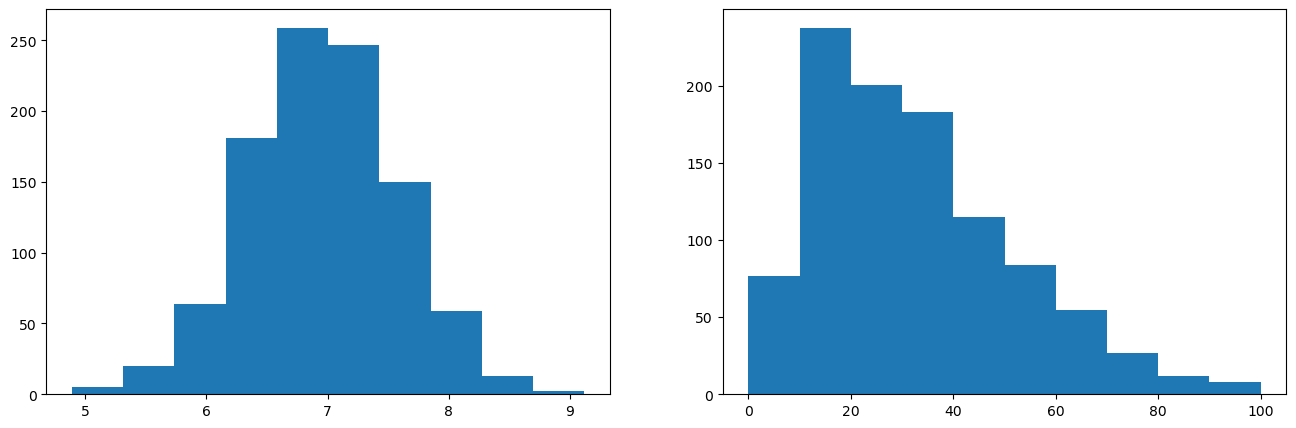

In [3]:
plt.figure(figsize=(16, 5))

plt.subplot(1,2,1)
plt.hist(df['cgpa'])

plt.subplot(1,2,2)
plt.hist(df['placement_exam_marks'])
plt.show()

In [4]:
# skewness
df['cgpa'].skew(), df['placement_exam_marks'].skew()

(-0.014529938929314918, 0.8356419499466834)

In [5]:
print("Mean : ", df['cgpa'].mean())
print("Stdev : ", df['cgpa'].std())
print("median : ", df['cgpa'].median())
print("max : ", df['cgpa'].max())
print("min : ", df['cgpa'].min())

Mean :  6.96124
Stdev :  0.6158978751323894
median :  6.96
max :  9.12
min :  4.89


<Axes: >

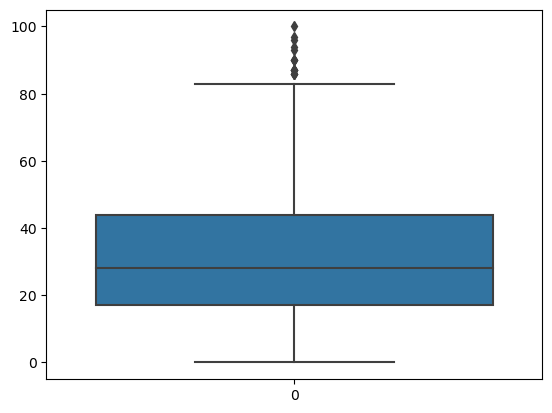

In [6]:
sns.boxplot(df['placement_exam_marks'])

In [7]:
 # finding the IQR
q1 = df['placement_exam_marks'].quantile(0.25) # or q*(n+1)
q2 = df['placement_exam_marks'].quantile(0.5)       # or .median()
q3 = df['placement_exam_marks'].quantile(0.75)
(q1, q2, q3)

(17.0, 28.0, 44.0)

In [8]:
iqr = q3 - q1
iqr

27.0

In [9]:
upper_lim = q3 + 1.5*iqr
lower_lim = q1 - 1.5*iqr
lower_lim, upper_lim

(-23.5, 84.5)

In [10]:
df[(df['placement_exam_marks'] > upper_lim) | (df['placement_exam_marks'] < lower_lim)]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


## Trimming

In [11]:
new_df = df[df['placement_exam_marks'] < upper_lim]
new_df.shape

(985, 3)

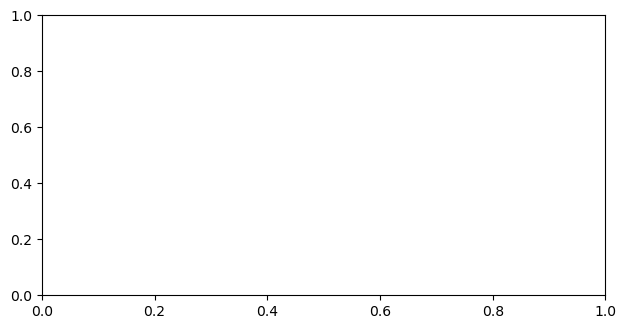

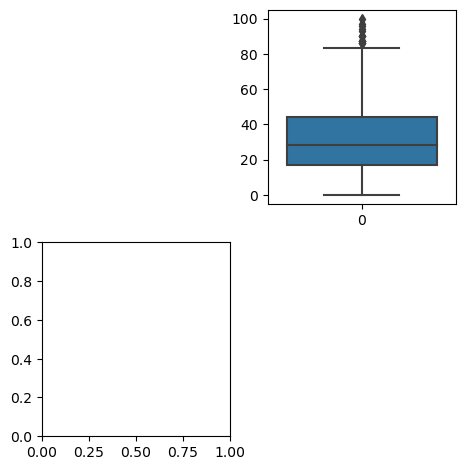

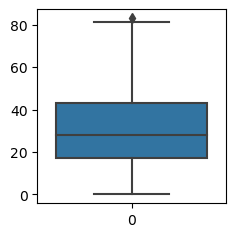

In [14]:
# comparing
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)
sns.displot(df['placement_exam_marks'])

plt.subplot(2, 2, 2)
sns.boxplot(df['placement_exam_marks'])


plt.subplot(2, 2, 3)
sns.displot(new_df['placement_exam_marks'])


plt.subplot(2, 2, 4)
sns.boxplot(new_df['placement_exam_marks'])
plt.show()